<h2>Formating of DB-Data<h2>

In [1]:
from hilfsfunktionen.formating import get_unchanged_table, get_formated_table, get_table_with_keys, create_n_sentences
df_collection = {}
df_collection["unchanged_table"] = get_unchanged_table()
df_collection["formated_table"] = get_formated_table()
df_collection["formated_table_with_keys"] = get_table_with_keys(df_collection["formated_table"])
df_collection["n_sentences"] = {}
for n in [1, 5, 20, 50, 100]:
    df_collection["n_sentences"][f"{n}"] = create_n_sentences(df_collection["formated_table_with_keys"], n)

<h2>Model Creation<h2>

In [2]:
from hilfsfunktionen.model_training import ModelGenerator
from pathlib import Path

base_params = {
            "vector_size": 150,
            "window": 4,
            "epochs": 30,
            "min_count": 1,
            "negative": 5,
            "sample": 1e-3,
            "hs": 0,
            "alpha": 0.025,
            "seed": 1,
            "num_sentences": 10000
        }
model_gen = ModelGenerator()
model_gen.set_base_values(base_params)
models, categories = model_gen.create_many_models(models = {}, n_sentences_tokenized = df_collection["n_sentences"], sentences_tokenized = df_collection["n_sentences"]["20"],base_dir = Path.cwd(), verbose = False)

Model Creation started.
Model Creation finished.


<h2>Durchschnittliche Satzvektoren berechnen<h2>

In [10]:
from hilfsfunktionen.sentence_vectors import create_average_sentence_vectors
average_sentence_vectors = {}
for category in categories:
    print(f"(-------------Vector calculation of category: {category.upper()}-------------)")
    average_sentence_vectors[category] = []
    i=0
    for model in models[category]:
        average_sentence_vectors[category].append([create_average_sentence_vectors(model, df_collection["formated_table_with_keys"], base_dir = Path.cwd(), verbose=False),model[1]])
    print(f"(-------------Finished Vector calculation of category: {category.upper()}-------------)")


(-------------Vector calculation of category: COMPARISON-------------)
(-------------Finished Vector calculation of category: COMPARISON-------------)
(-------------Vector calculation of category: SENTENCES-------------)
(-------------Finished Vector calculation of category: SENTENCES-------------)
(-------------Vector calculation of category: VECTOR-------------)
(-------------Finished Vector calculation of category: VECTOR-------------)
(-------------Vector calculation of category: WINDOWSIZE-------------)
(-------------Finished Vector calculation of category: WINDOWSIZE-------------)
(-------------Vector calculation of category: EPOCH-------------)
(-------------Finished Vector calculation of category: EPOCH-------------)
(-------------Vector calculation of category: NEGATIVE-------------)
(-------------Finished Vector calculation of category: NEGATIVE-------------)
(-------------Vector calculation of category: SAMPLE-------------)
(-------------Finished Vector calculation of catego

<h2>Vektoren-Test Textbasiert<h2>

In [4]:
from hilfsfunktionen.basic_vector_tests import run_full_quality_check
from hilfsfunktionen.key_vector_tests import run_full_quality_check_key
from hilfsfunktionen.cosine_tests import run_full_vector_test
    
def run_all_tests(model,verbose):
    run_full_quality_check(model, verbose)
    run_full_quality_check_key(model, verbose, df_with_keys = df_collection["formated_table_with_keys"])
    run_full_vector_test(model, verbose, df_with_keys = df_collection["formated_table_with_keys"])

In [5]:
if False:
    for category in categories:
        print(f"(-------------Test of category: {category.upper()}-------------)\n")
        for model in models[category]:
            run_all_tests(model,False)

<h2>Visualisierung<h2>

In [6]:
from hilfsfunktionen.visualise_vectors import print_model_metrics, visualize_all_models, visualize_model_comparison
def visualize_model(model, method):
    print_model_metrics(model)
    visualize_all_models(model, method)
    #visualize_model_comparison(model)

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
if False:
    for category in categories:
        print(f"(-------------Test of category: {category.upper()}-------------)\n")
        visualize_model(models[category], method="tsne")

In [8]:
from hilfsfunktionen.visualise_avr_sent import visualize_all_avr_sent, print_avr_sent_metrics
def visualize_avr_sent(model, method):
    print_avr_sent_metrics(model)
    visualize_all_avr_sent(model, method)

(-------------Test of category: COMPARISON-------------)

<class 'pandas.core.series.Series'>
Key_0       [[0.44882962, -0.29054567, -0.35367754, -0.371...
Key_1       [[0.18012716, -0.2950205, -0.32141724, -0.1749...
Key_2       [[0.25830114, 0.09542136, -0.37234494, -0.1260...
Key_3       [[0.33629125, -0.13378705, -0.024897443, -0.19...
Key_4       [[0.43375129, -0.02823208, -0.3840463, -0.0821...
                                  ...                        
Key_9995    [[0.4319562, -0.065342456, -0.20021482, -0.064...
Key_9996    [[0.41610613, -0.22144192, -0.44407493, -0.069...
Key_9997    [[0.45379522, 0.013416236, -0.19057217, -0.325...
Key_9998    [[0.56517315, 0.1227349, -0.21684018, 0.131651...
Key_9999    [[0.24703597, 0.2989816, -0.35433677, -0.01898...
Length: 10000, dtype: object
vektor_series  Epoch  Ne Sa  Worke  Seed  Kl Wo  Satza  Sampl  Algor  Ve Si  Windo  Hi So  Satzl  Alpha  Vo Si
------------------------------------------------------------------------------------

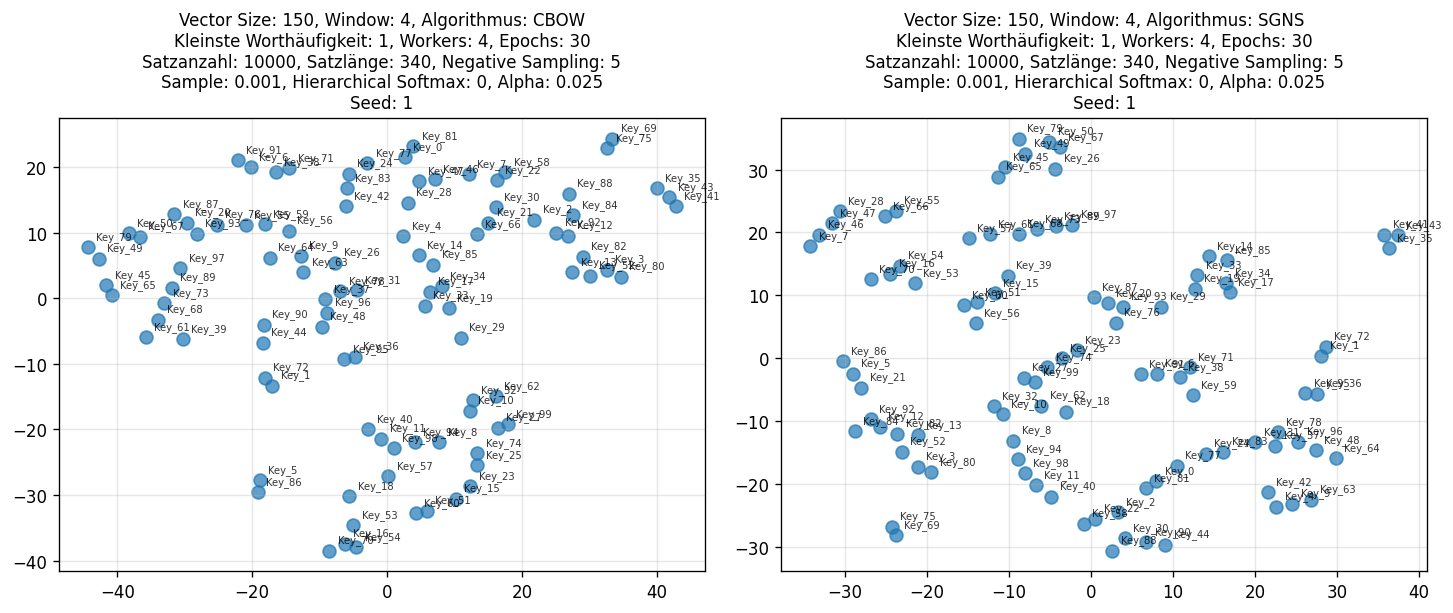

Erste Darstellung erfolgreich.
(-------------Test of category: SENTENCES-------------)

<class 'pandas.core.series.Series'>
Key_0       [[-0.24348415, -0.19387232, -0.21158825, -0.23...
Key_1       [[-0.12836514, -0.2234148, 0.014442986, -0.064...
Key_2       [[-0.338652, -0.10371378, -0.056769036, -0.176...
Key_3       [[-0.23950504, -0.15849973, 0.031006964, 0.004...
Key_4       [[-0.0037997798, -0.20670505, 0.0883627, -0.28...
                                  ...                        
Key_9995    [[-0.21997899, -0.15286003, 0.08108178, -0.217...
Key_9996    [[-0.15469289, -0.18421529, -0.024938816, -0.2...
Key_9997    [[-0.03485444, 0.047181033, -0.0733325, -0.266...
Key_9998    [[-0.112504505, -0.0731481, 0.1308902, -0.1268...
Key_9999    [[-0.105818205, -0.103740886, -0.048319425, -0...
Length: 10000, dtype: object
vektor_series  Epoch  Ne Sa  Worke  Seed  Kl Wo  Satza  Sampl  Algor  Ve Si  Windo  Hi So  Satzl  Alpha  Vo Si
------------------------------------------------------

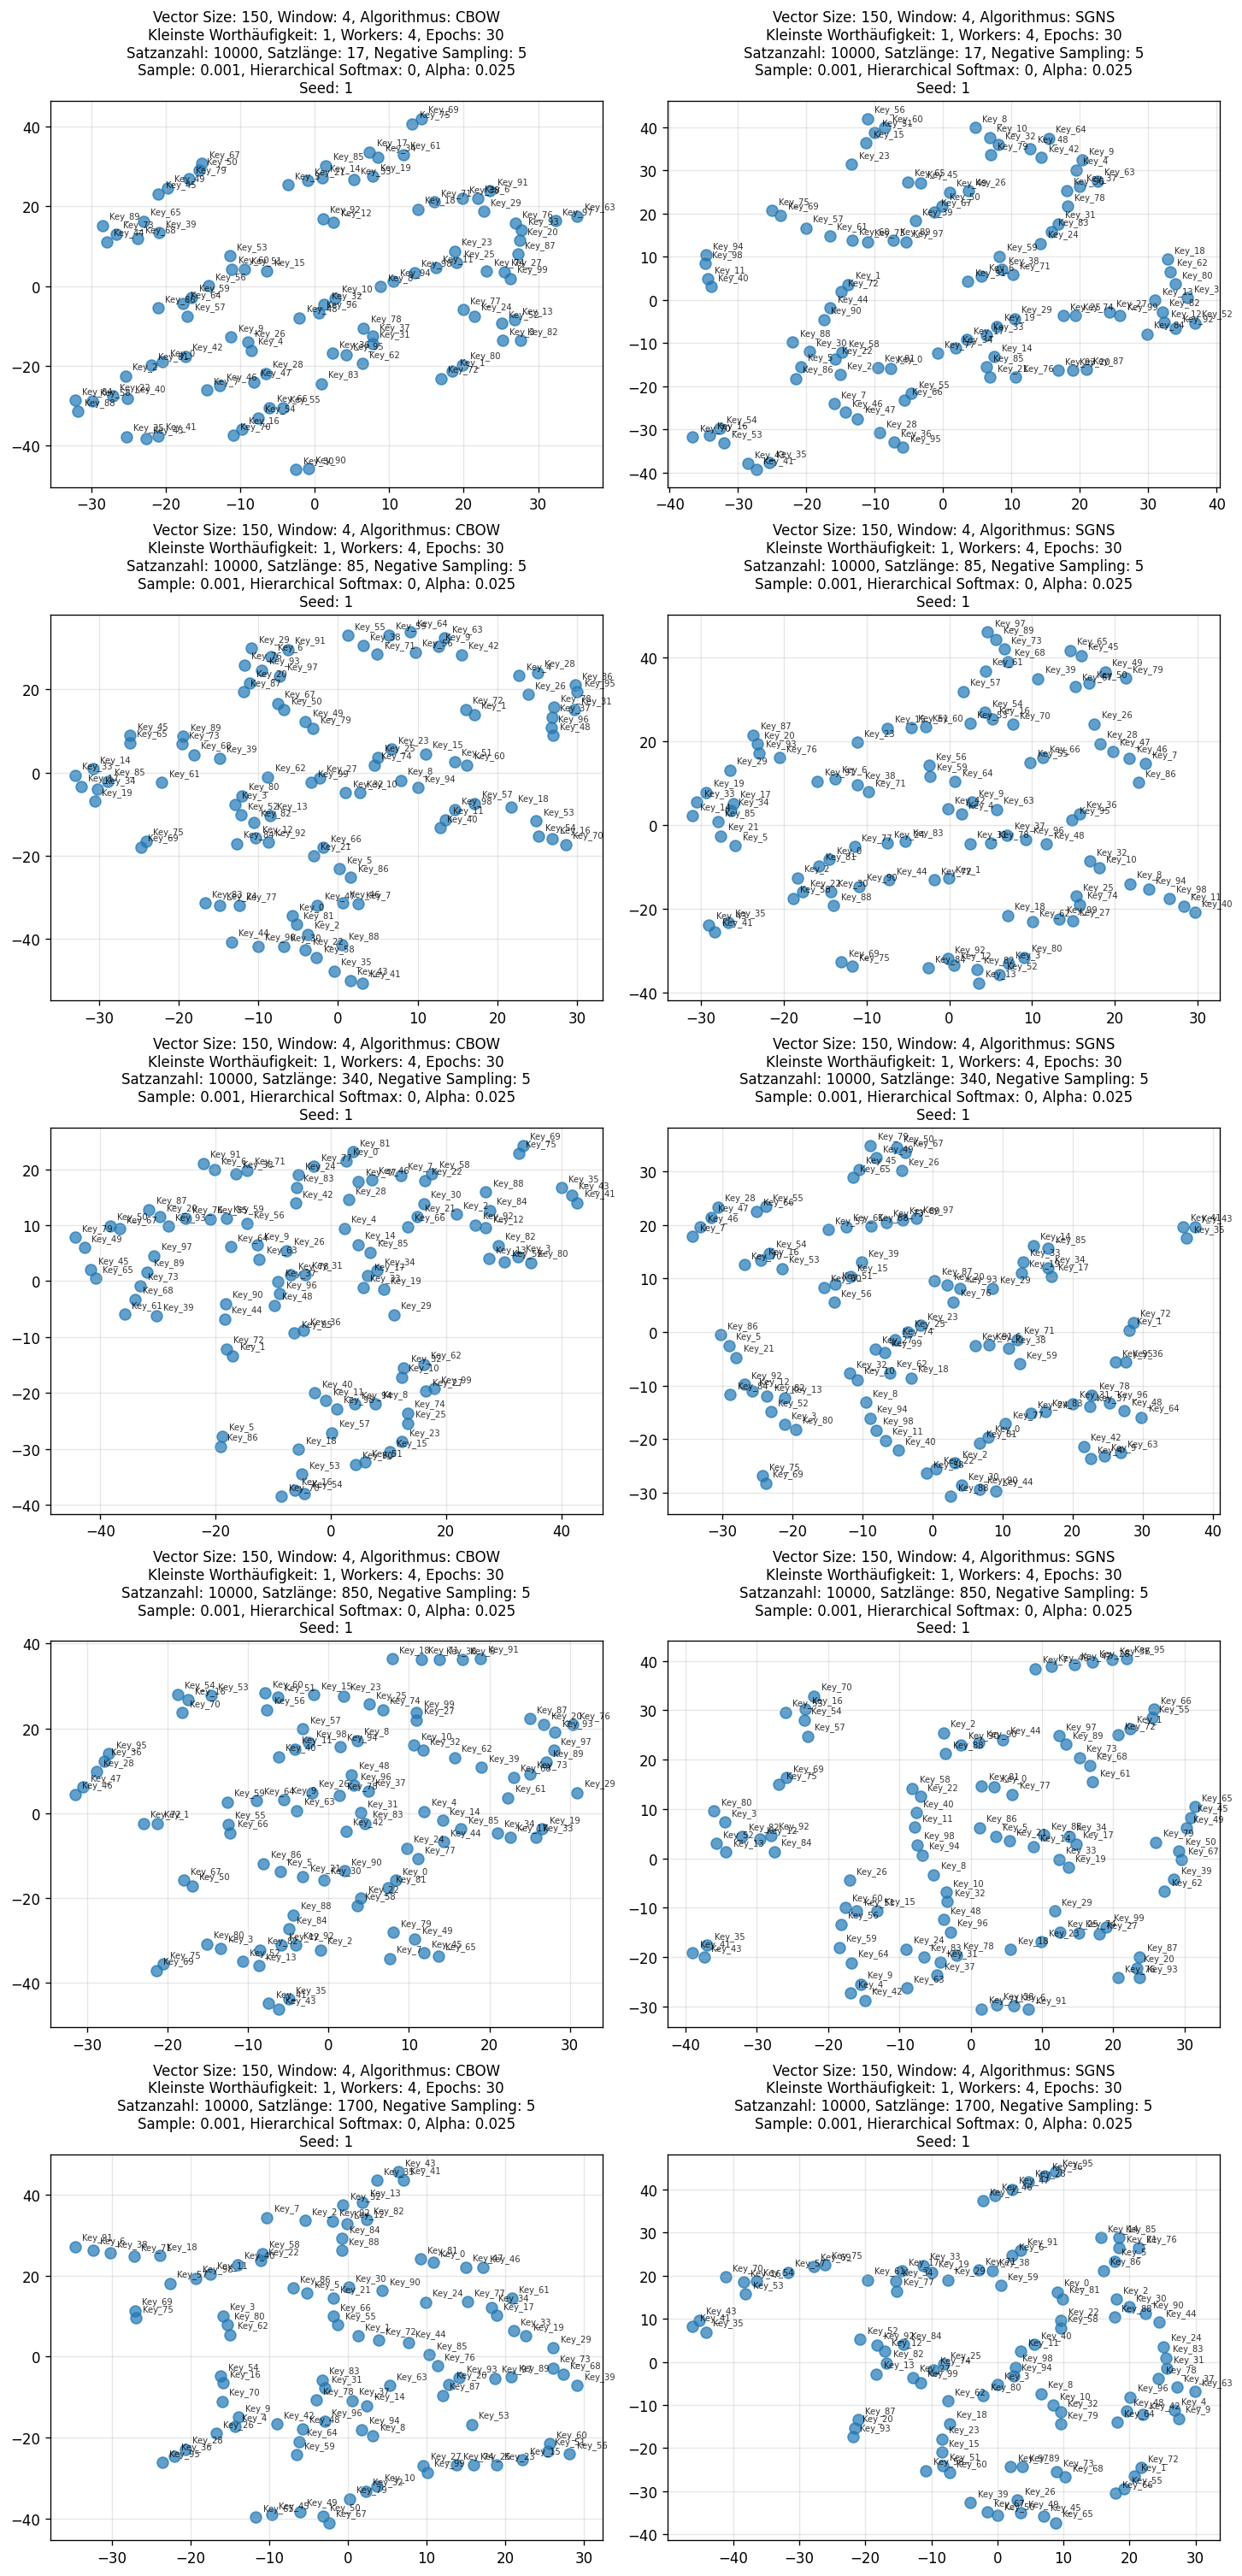

Erste Darstellung erfolgreich.
(-------------Test of category: VECTOR-------------)

<class 'pandas.core.series.Series'>
Key_0       [[0.48183462, 0.21525775, 0.2531295, -0.189300...
Key_1       [[0.607836, 0.025193185, 0.14482515, -0.509051...
Key_2       [[0.17637715, 0.2466922, 0.1912415, -0.2949568...
Key_3       [[0.35553977, 0.0033935443, 0.354396, -0.30006...
Key_4       [[0.24622677, 0.029866947, 0.15389185, -0.2518...
                                  ...                        
Key_9995    [[0.16579556, 0.33244458, 0.14527248, 0.019756...
Key_9996    [[0.21193253, 0.007192862, 0.024921926, -0.060...
Key_9997    [[0.40053225, -0.027089508, 0.30278412, -0.082...
Key_9998    [[0.27749503, 0.39097646, 0.08623936, -0.38150...
Key_9999    [[0.6814237, -0.091012925, 0.12161192, -0.2326...
Length: 10000, dtype: object
vektor_series  Epoch  Ne Sa  Worke  Seed  Kl Wo  Satza  Sampl  Algor  Ve Si  Windo  Hi So  Satzl  Alpha  Vo Si
---------------------------------------------------------

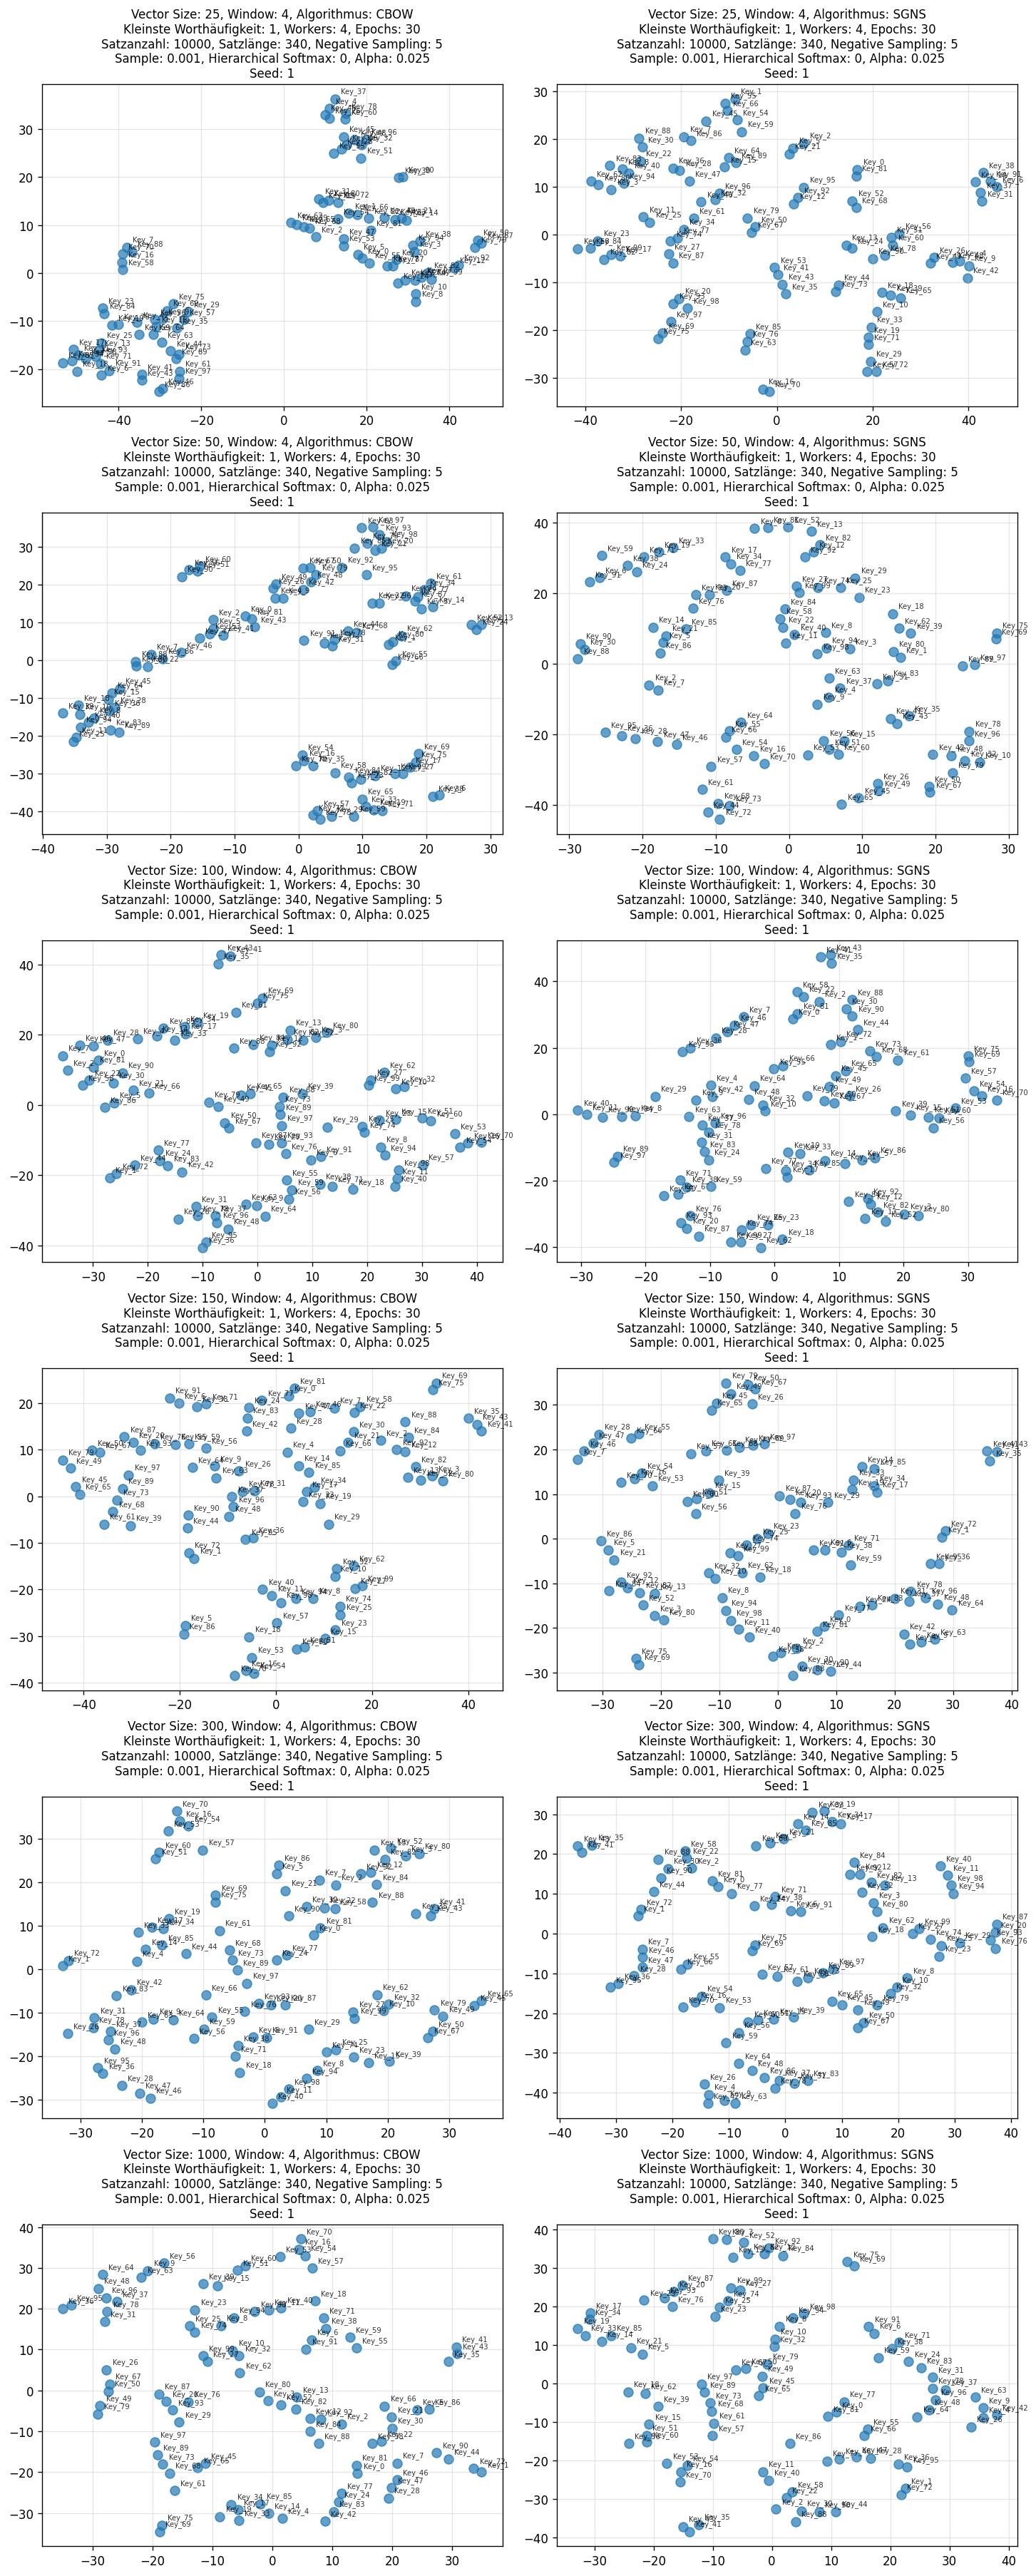

Erste Darstellung erfolgreich.
(-------------Test of category: WINDOWSIZE-------------)

<class 'pandas.core.series.Series'>
Key_0       [[-0.0016854595, -0.1687574, -0.41003868, -0.4...
Key_1       [[0.085843794, -0.2215092, -0.37953913, -0.286...
Key_2       [[-0.0066163, -0.079303116, -0.5044951, -0.454...
Key_3       [[0.025038563, -0.04559566, -0.33792514, -0.37...
Key_4       [[0.22773887, -0.10736745, -0.38120854, -0.300...
                                  ...                        
Key_9995    [[-0.050776146, 0.16747111, -0.5091848, -0.437...
Key_9996    [[-0.113906, -0.17146854, -0.4083352, -0.32576...
Key_9997    [[-0.050605547, -0.032087233, -0.47129124, -0....
Key_9998    [[0.17583993, -0.061063923, -0.6021445, -0.345...
Key_9999    [[0.038380306, 0.19556269, -0.7709249, -0.4817...
Length: 10000, dtype: object
vektor_series  Epoch  Ne Sa  Worke  Seed  Kl Wo  Satza  Sampl  Algor  Ve Si  Windo  Hi So  Satzl  Alpha  Vo Si
-----------------------------------------------------

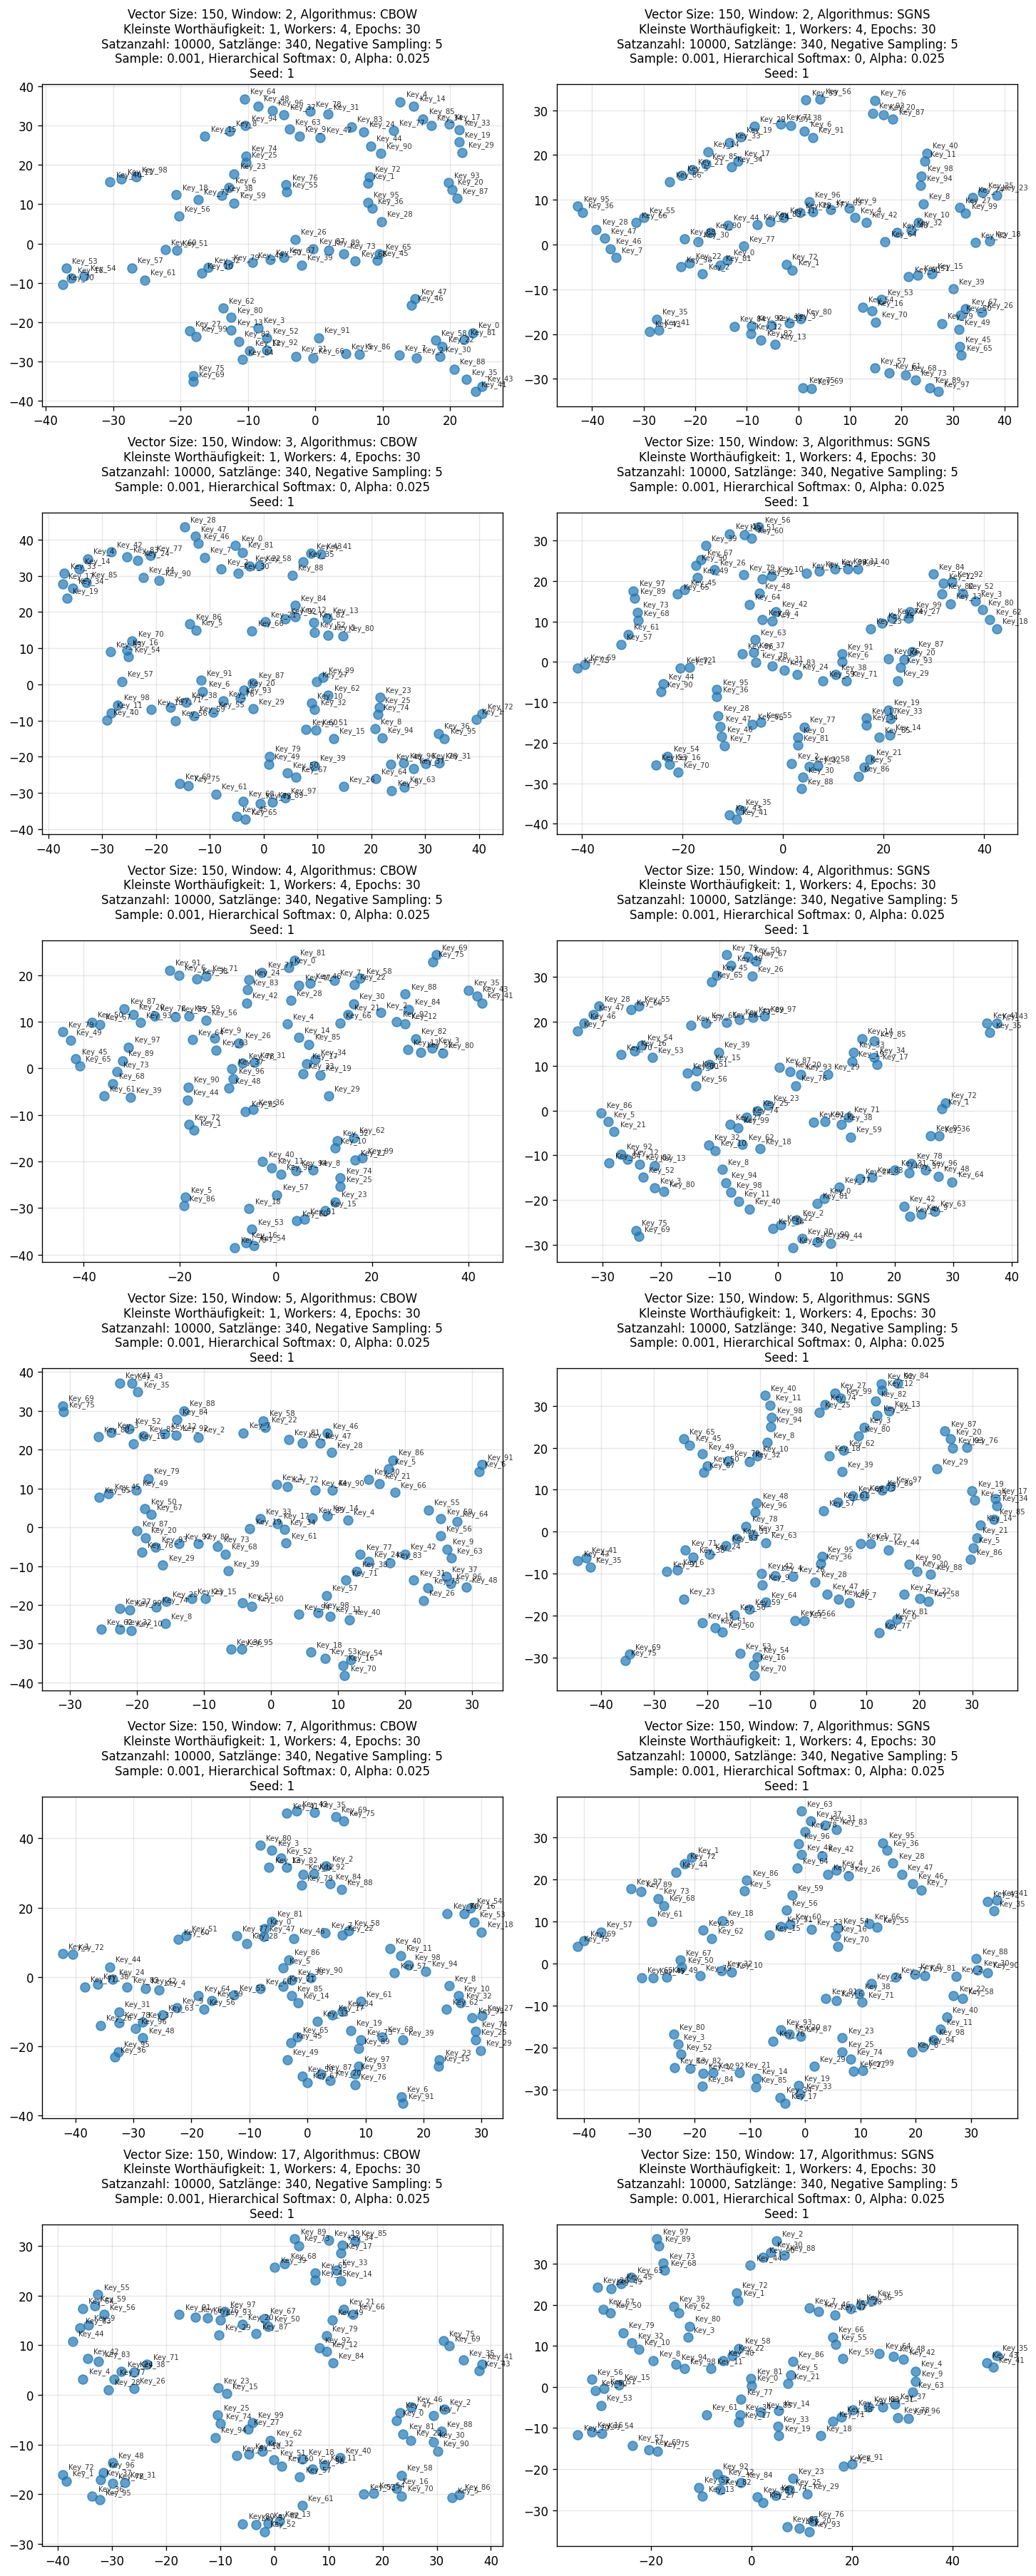

Erste Darstellung erfolgreich.
(-------------Test of category: EPOCH-------------)

<class 'pandas.core.series.Series'>
Key_0       [[0.45932466, -0.26132002, -0.5921152, -0.0967...
Key_1       [[0.21642087, -0.41042253, -0.35534975, 0.0438...
Key_2       [[0.50734097, -0.21045657, -0.5431496, -0.0159...
Key_3       [[0.22474717, -0.52530116, -0.22701679, -0.138...
Key_4       [[0.4012315, -0.35381794, -0.6759659, 0.051365...
                                  ...                        
Key_9995    [[0.3159858, -0.2225387, -0.3658555, -0.237372...
Key_9996    [[0.16186167, -0.4336383, -0.44824162, -0.1364...
Key_9997    [[0.31786206, -0.2857964, -0.4188979, -0.10807...
Key_9998    [[0.54163986, -0.26441795, -0.40896147, -0.056...
Key_9999    [[0.196594, -0.35275277, -0.6732174, -0.216026...
Length: 10000, dtype: object
vektor_series  Epoch  Ne Sa  Worke  Seed  Kl Wo  Satza  Sampl  Algor  Ve Si  Windo  Hi So  Satzl  Alpha  Vo Si
----------------------------------------------------------

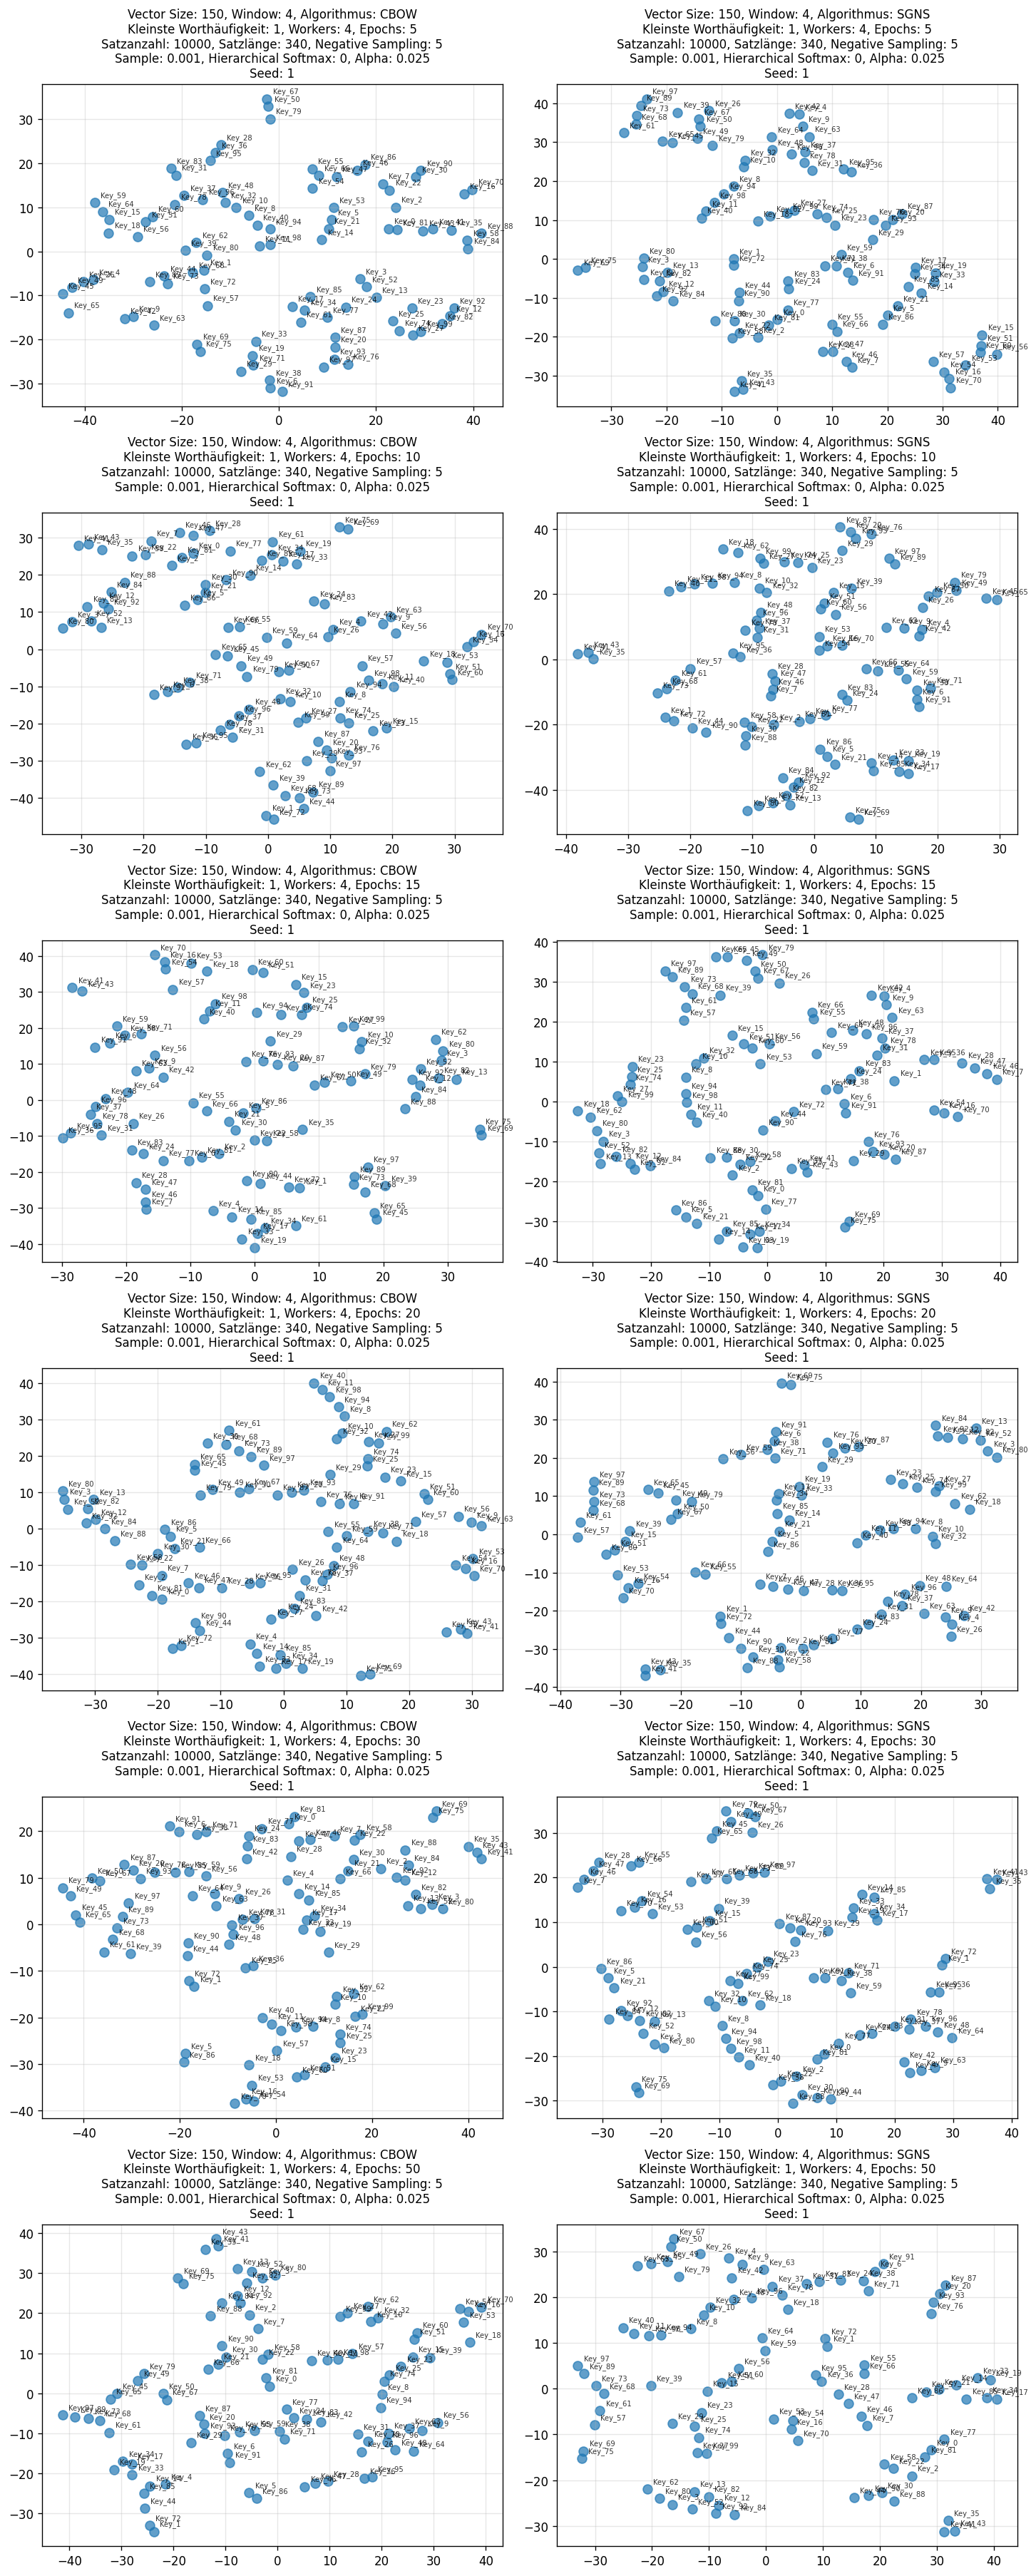

Erste Darstellung erfolgreich.
(-------------Test of category: NEGATIVE-------------)

<class 'pandas.core.series.Series'>
Key_0       [[0.44882962, -0.29054567, -0.35367754, -0.371...
Key_1       [[0.18012716, -0.2950205, -0.32141724, -0.1749...
Key_2       [[0.25830114, 0.09542136, -0.37234494, -0.1260...
Key_3       [[0.33629125, -0.13378705, -0.024897443, -0.19...
Key_4       [[0.43375129, -0.02823208, -0.3840463, -0.0821...
                                  ...                        
Key_9995    [[0.4319562, -0.065342456, -0.20021482, -0.064...
Key_9996    [[0.41610613, -0.22144192, -0.44407493, -0.069...
Key_9997    [[0.45379522, 0.013416236, -0.19057217, -0.325...
Key_9998    [[0.56517315, 0.1227349, -0.21684018, 0.131651...
Key_9999    [[0.24703597, 0.2989816, -0.35433677, -0.01898...
Length: 10000, dtype: object
vektor_series  Epoch  Ne Sa  Worke  Seed  Kl Wo  Satza  Sampl  Algor  Ve Si  Windo  Hi So  Satzl  Alpha  Vo Si
-------------------------------------------------------

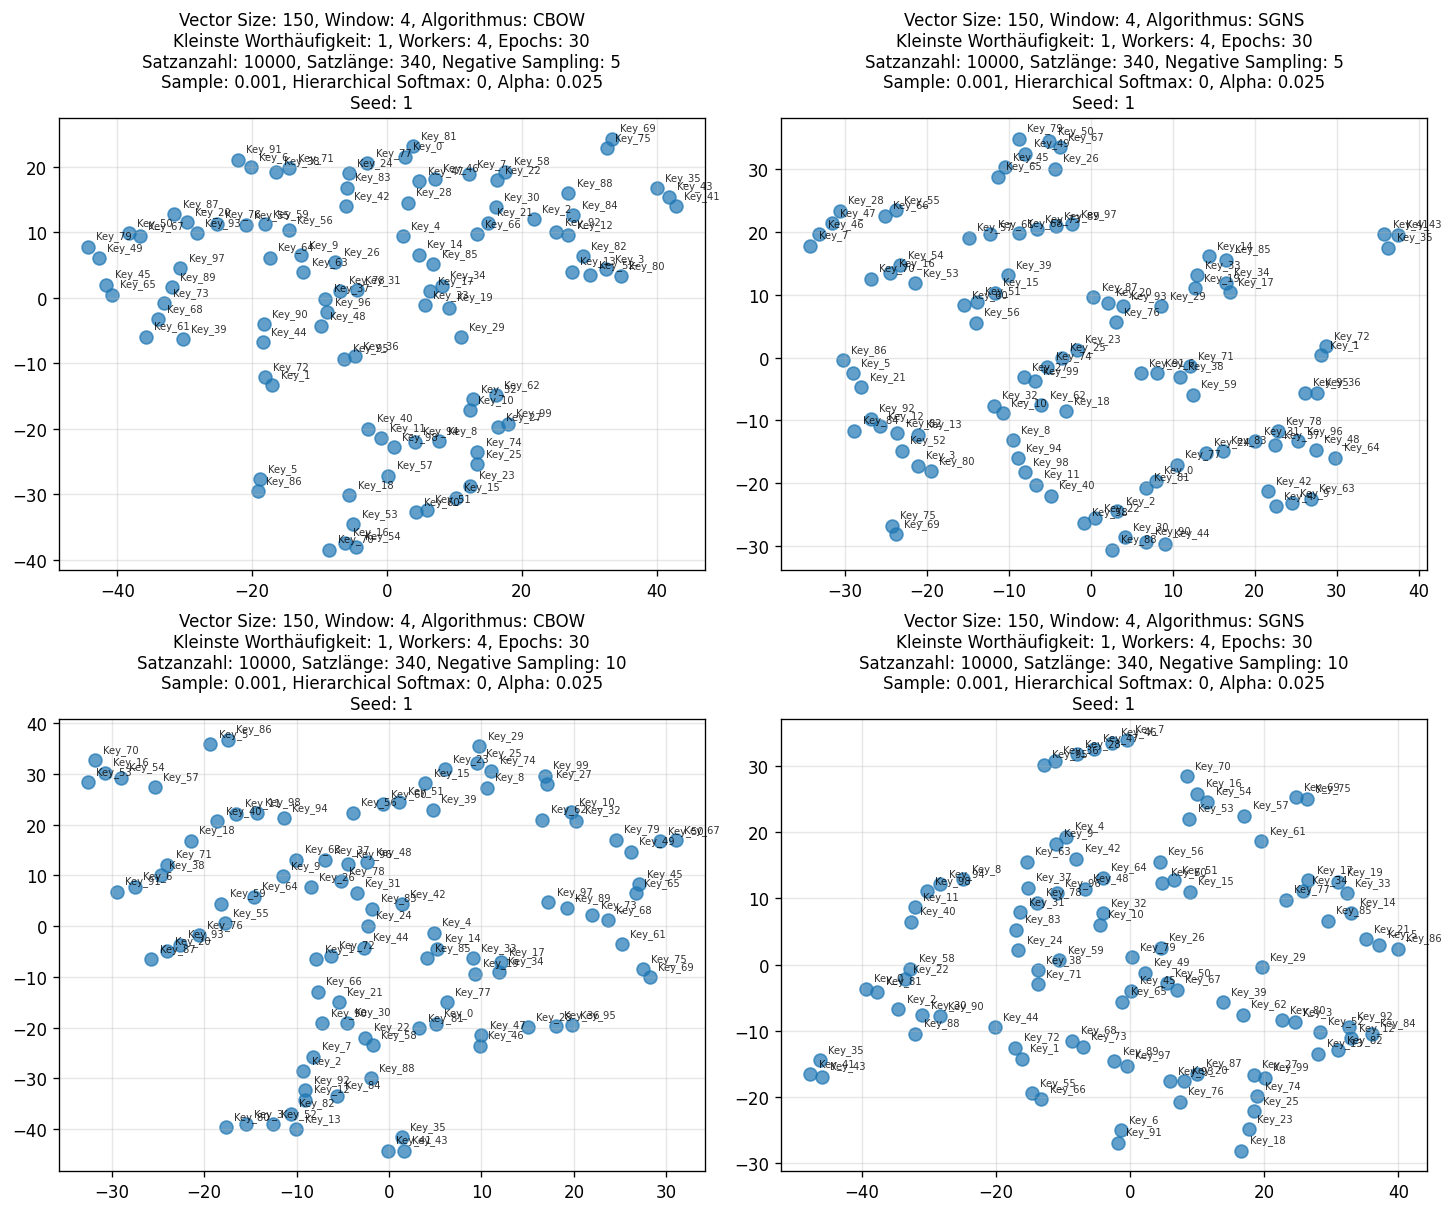

Erste Darstellung erfolgreich.
(-------------Test of category: SAMPLE-------------)

<class 'pandas.core.series.Series'>
Key_0       [[0.44882962, -0.29054567, -0.35367754, -0.371...
Key_1       [[0.18012716, -0.2950205, -0.32141724, -0.1749...
Key_2       [[0.25830114, 0.09542136, -0.37234494, -0.1260...
Key_3       [[0.33629125, -0.13378705, -0.024897443, -0.19...
Key_4       [[0.43375129, -0.02823208, -0.3840463, -0.0821...
                                  ...                        
Key_9995    [[0.4319562, -0.065342456, -0.20021482, -0.064...
Key_9996    [[0.41610613, -0.22144192, -0.44407493, -0.069...
Key_9997    [[0.45379522, 0.013416236, -0.19057217, -0.325...
Key_9998    [[0.56517315, 0.1227349, -0.21684018, 0.131651...
Key_9999    [[0.24703597, 0.2989816, -0.35433677, -0.01898...
Length: 10000, dtype: object
vektor_series  Epoch  Ne Sa  Worke  Seed  Kl Wo  Satza  Sampl   Algor  Ve Si  Windo  Hi So  Satzl  Alpha  Vo Si
--------------------------------------------------------

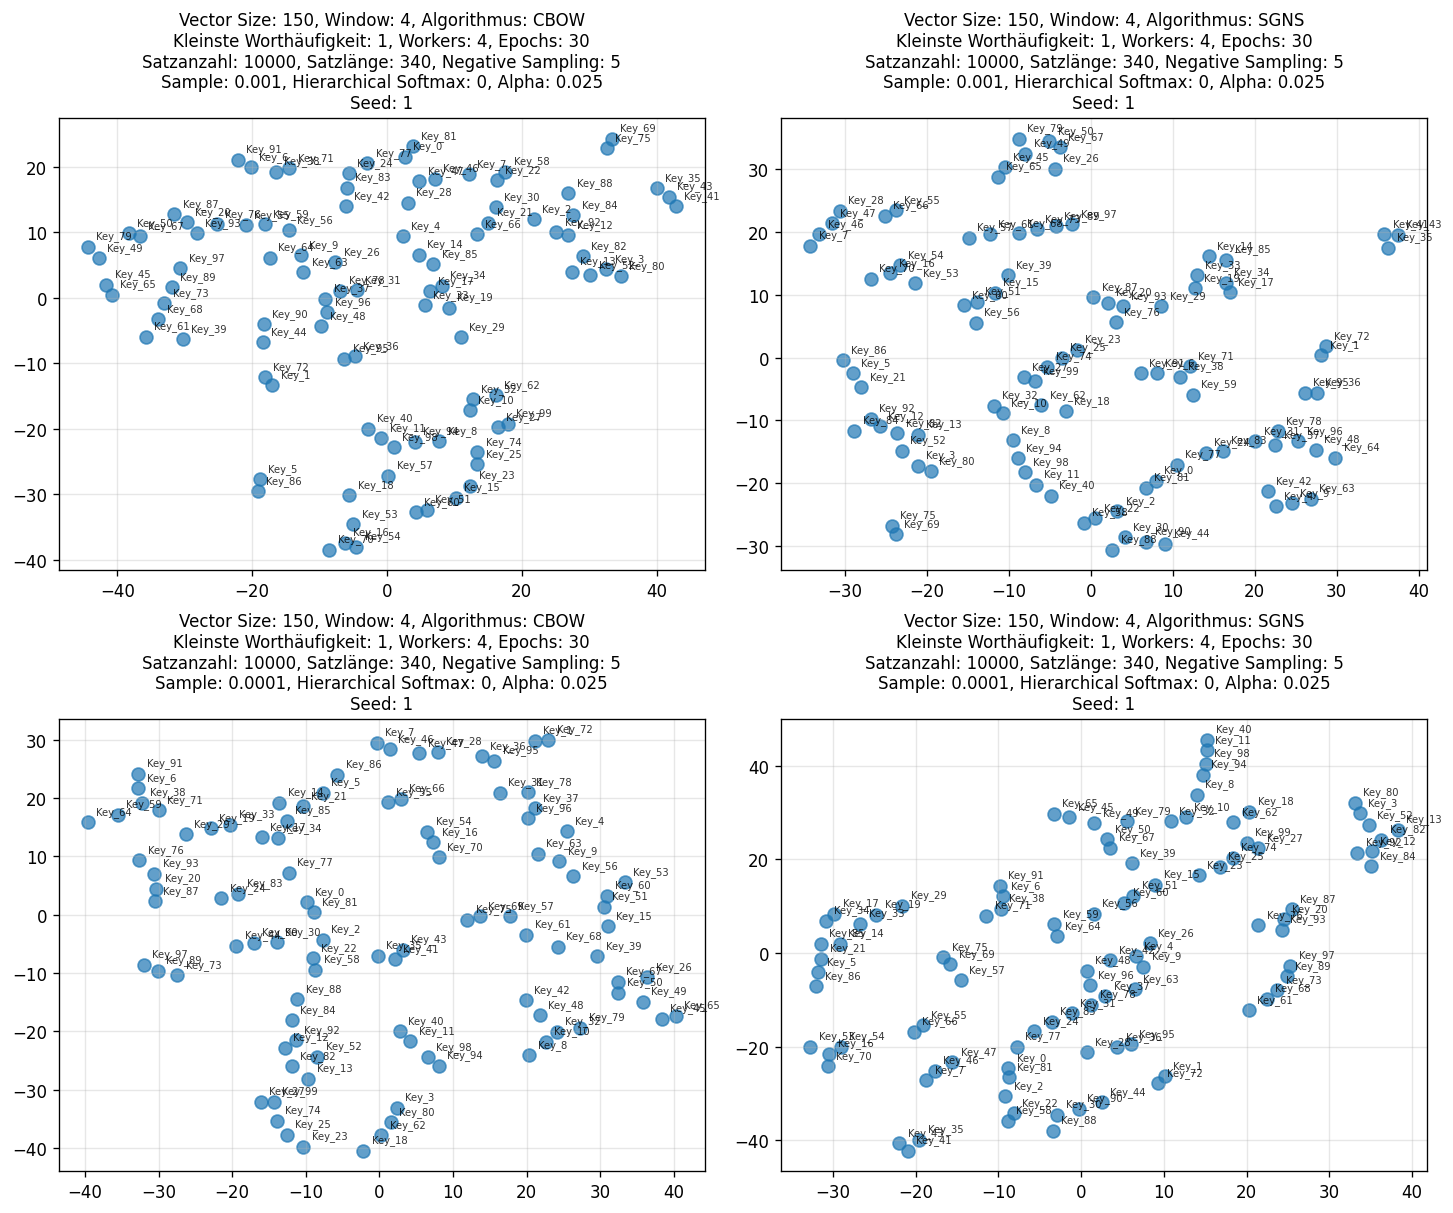

Erste Darstellung erfolgreich.
(-------------Test of category: HS-------------)

<class 'pandas.core.series.Series'>
Key_0       [[0.44882962, -0.29054567, -0.35367754, -0.371...
Key_1       [[0.18012716, -0.2950205, -0.32141724, -0.1749...
Key_2       [[0.25830114, 0.09542136, -0.37234494, -0.1260...
Key_3       [[0.33629125, -0.13378705, -0.024897443, -0.19...
Key_4       [[0.43375129, -0.02823208, -0.3840463, -0.0821...
                                  ...                        
Key_9995    [[0.4319562, -0.065342456, -0.20021482, -0.064...
Key_9996    [[0.41610613, -0.22144192, -0.44407493, -0.069...
Key_9997    [[0.45379522, 0.013416236, -0.19057217, -0.325...
Key_9998    [[0.56517315, 0.1227349, -0.21684018, 0.131651...
Key_9999    [[0.24703597, 0.2989816, -0.35433677, -0.01898...
Length: 10000, dtype: object
vektor_series  Epoch  Ne Sa  Worke  Seed  Kl Wo  Satza  Sampl  Algor  Ve Si  Windo  Hi So  Satzl  Alpha  Vo Si
-------------------------------------------------------------

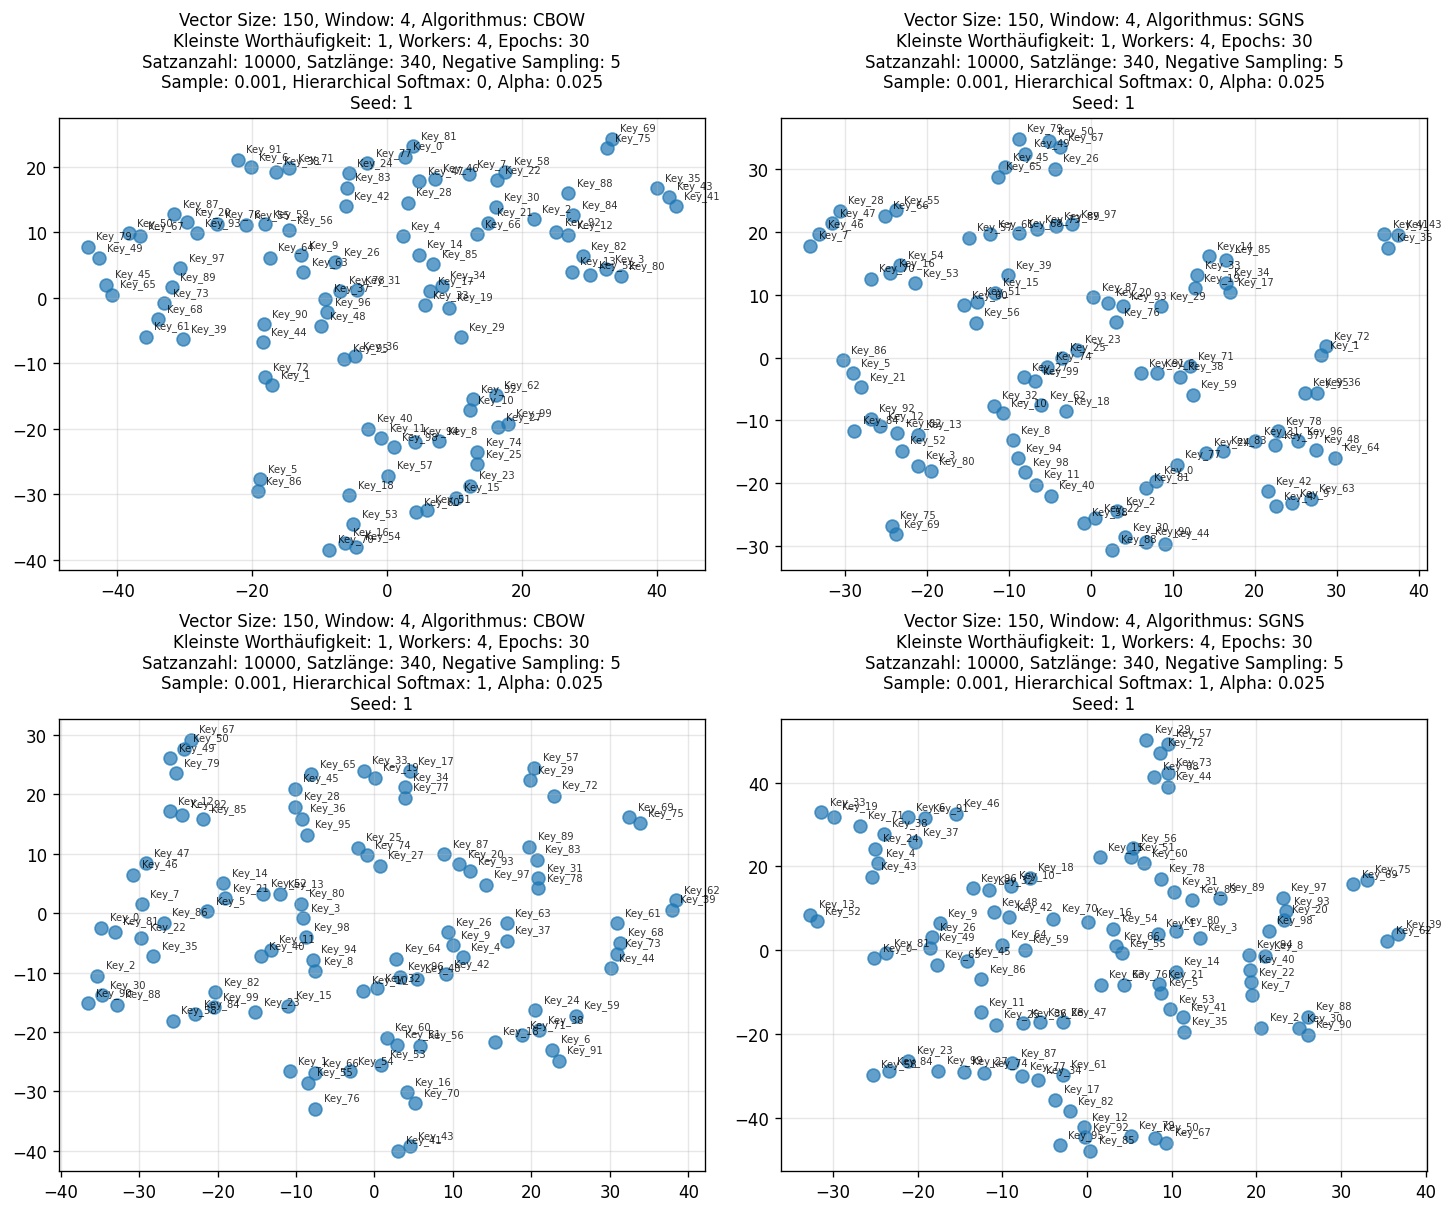

Erste Darstellung erfolgreich.
(-------------Test of category: ALPHA-------------)

<class 'pandas.core.series.Series'>
Key_0       [[0.44882962, -0.29054567, -0.35367754, -0.371...
Key_1       [[0.18012716, -0.2950205, -0.32141724, -0.1749...
Key_2       [[0.25830114, 0.09542136, -0.37234494, -0.1260...
Key_3       [[0.33629125, -0.13378705, -0.024897443, -0.19...
Key_4       [[0.43375129, -0.02823208, -0.3840463, -0.0821...
                                  ...                        
Key_9995    [[0.4319562, -0.065342456, -0.20021482, -0.064...
Key_9996    [[0.41610613, -0.22144192, -0.44407493, -0.069...
Key_9997    [[0.45379522, 0.013416236, -0.19057217, -0.325...
Key_9998    [[0.56517315, 0.1227349, -0.21684018, 0.131651...
Key_9999    [[0.24703597, 0.2989816, -0.35433677, -0.01898...
Length: 10000, dtype: object
vektor_series  Epoch  Ne Sa  Worke  Seed  Kl Wo  Satza  Sampl  Algor  Ve Si  Windo  Hi So  Satzl  Alpha  Vo Si
----------------------------------------------------------

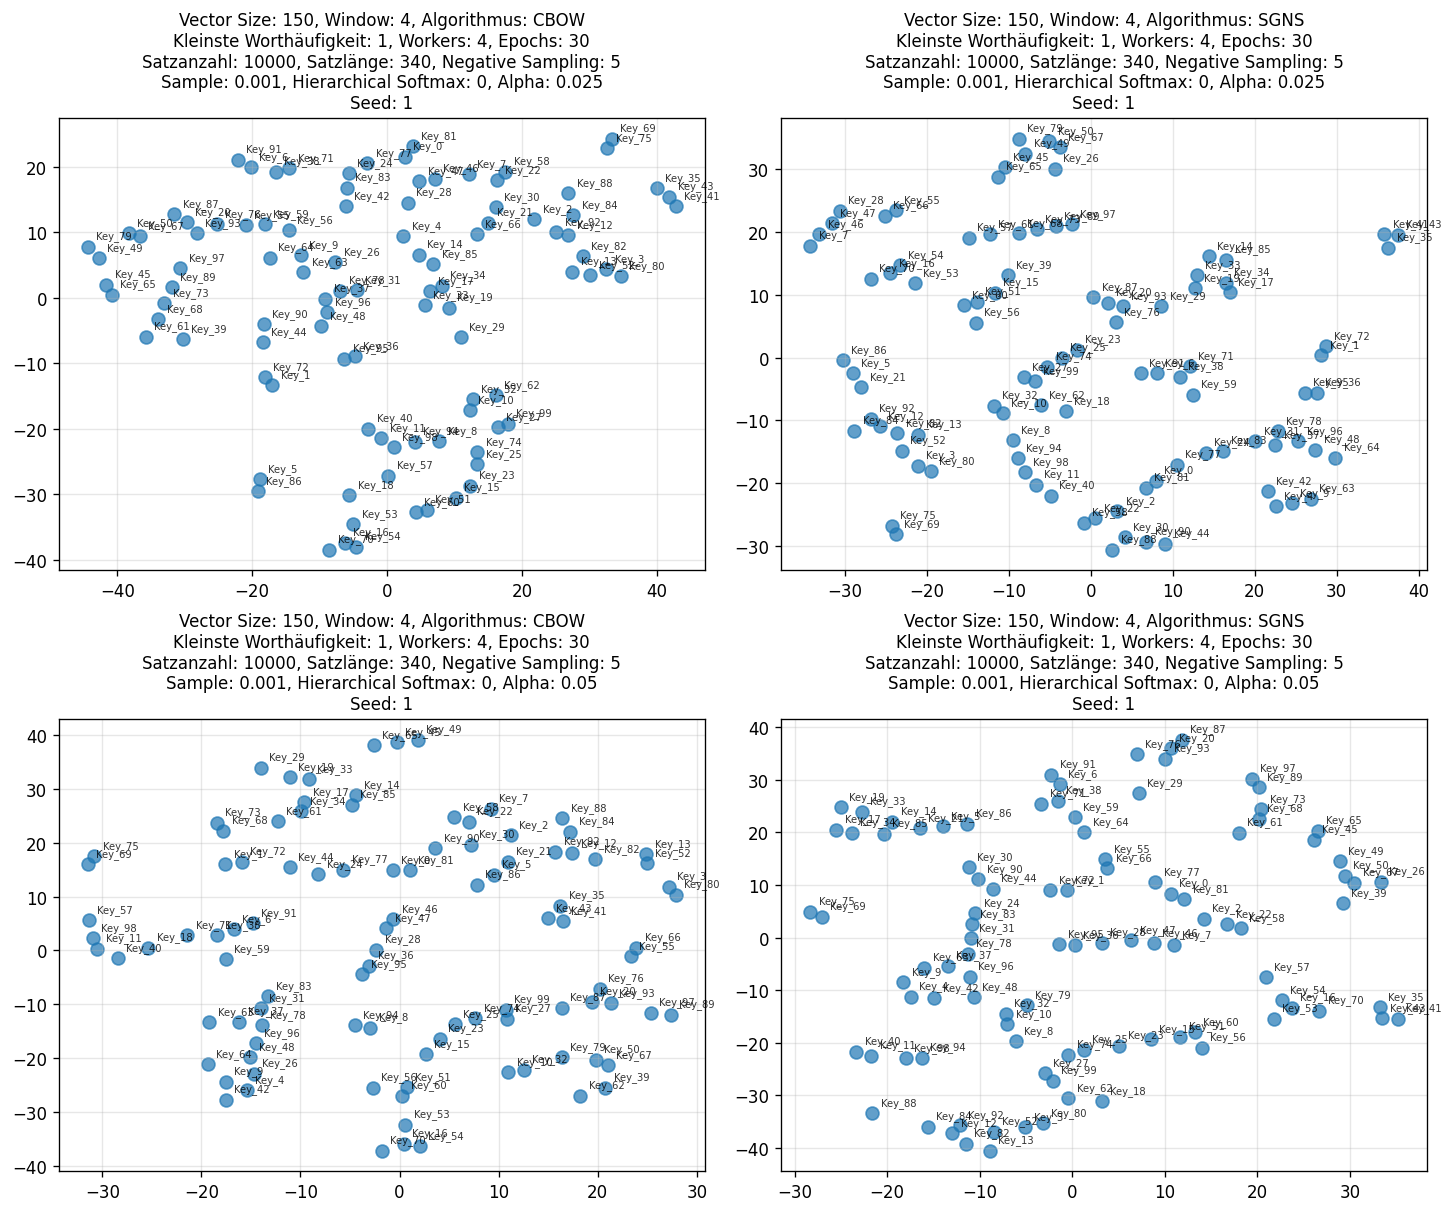

Erste Darstellung erfolgreich.
(-------------Test of category: SEED-------------)

<class 'pandas.core.series.Series'>
Key_0       [[0.44882962, -0.29054567, -0.35367754, -0.371...
Key_1       [[0.18012716, -0.2950205, -0.32141724, -0.1749...
Key_2       [[0.25830114, 0.09542136, -0.37234494, -0.1260...
Key_3       [[0.33629125, -0.13378705, -0.024897443, -0.19...
Key_4       [[0.43375129, -0.02823208, -0.3840463, -0.0821...
                                  ...                        
Key_9995    [[0.4319562, -0.065342456, -0.20021482, -0.064...
Key_9996    [[0.41610613, -0.22144192, -0.44407493, -0.069...
Key_9997    [[0.45379522, 0.013416236, -0.19057217, -0.325...
Key_9998    [[0.56517315, 0.1227349, -0.21684018, 0.131651...
Key_9999    [[0.24703597, 0.2989816, -0.35433677, -0.01898...
Length: 10000, dtype: object
vektor_series  Epoch  Ne Sa  Worke  Seed  Kl Wo  Satza  Sampl  Algor  Ve Si  Windo  Hi So  Satzl  Alpha  Vo Si
-----------------------------------------------------------

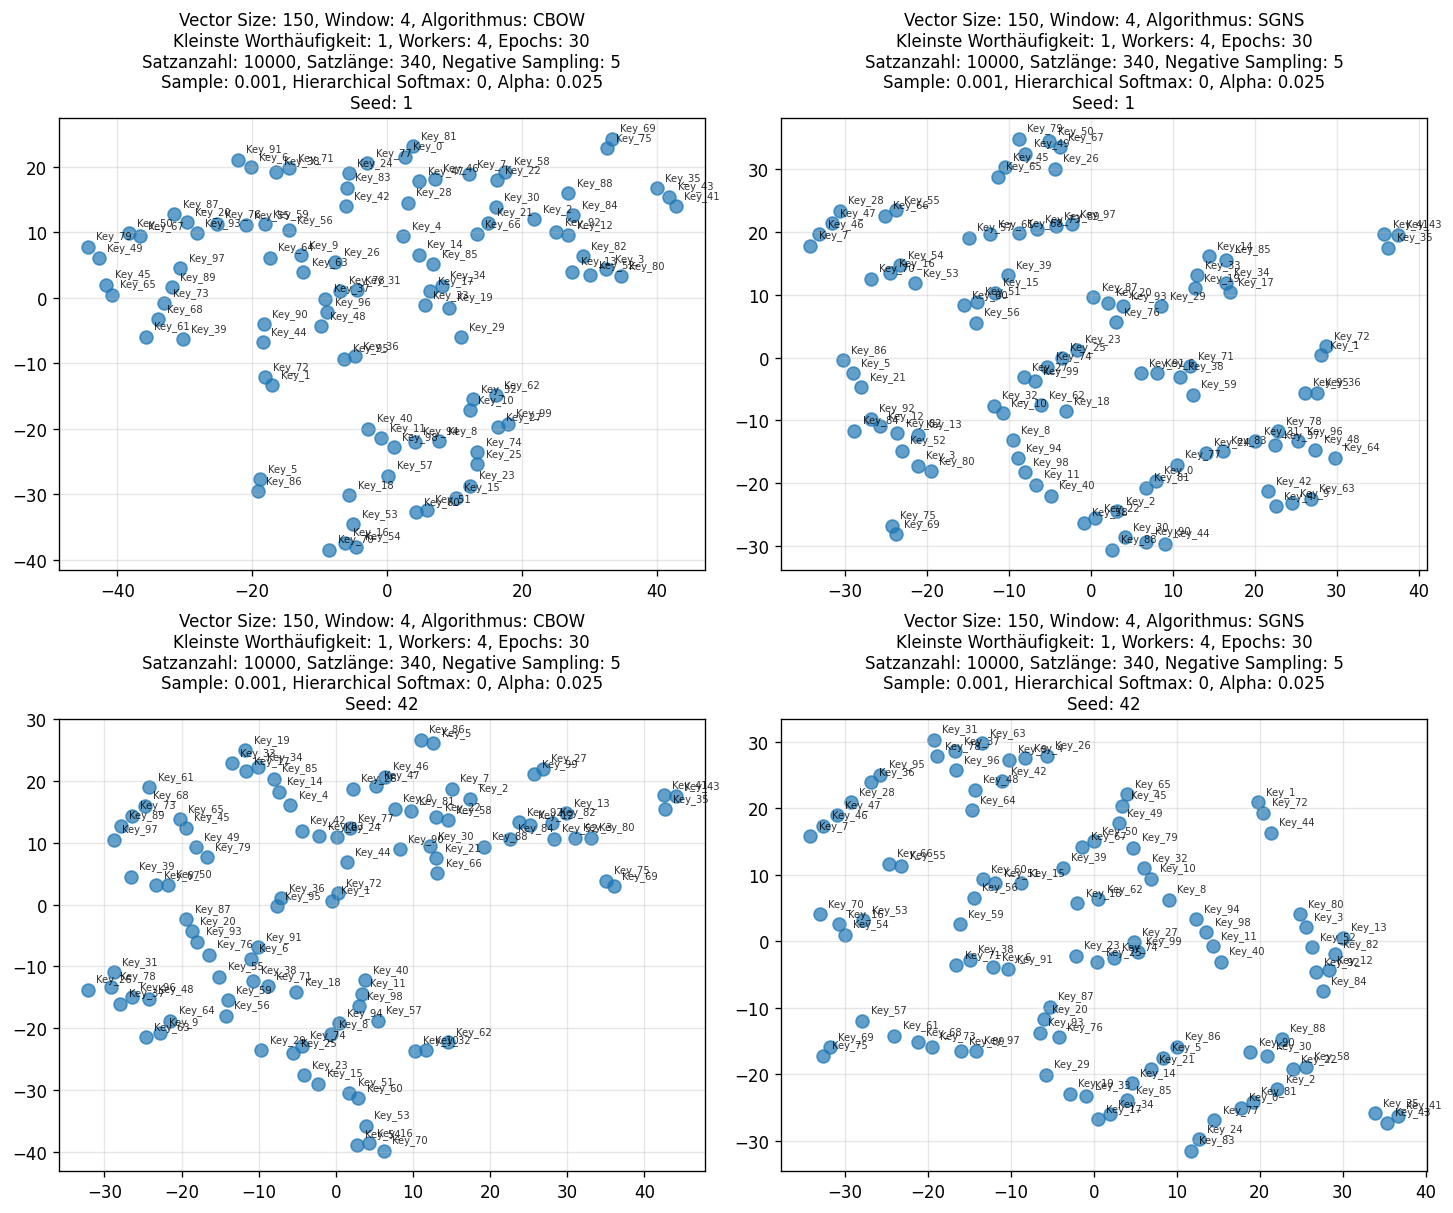

Erste Darstellung erfolgreich.


In [9]:
if True:
    for category in categories:
        print(f"(-------------Test of category: {category.upper()}-------------)\n")
        print(type(average_sentence_vectors[category][1][0]))
        print(average_sentence_vectors[category][1][0])
        visualize_avr_sent(average_sentence_vectors[category], method="tsne")